# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hamza-Ali0719/FlyRank-ML-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
import os
import json

# Load data
df = pd.read_csv("content_refresh_anonymized.csv")
print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Clean data
df_clean = df.dropna(subset=['clicks_90d'])
feature_cols = [
    'search_volume',
    'competition',
    'word_count',
    'char_count',
    'content_age_days',
    'days_since_last_update'
]

for col in feature_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

print(f"✅ Clean rows: {df_clean.shape[0]}")

# Sort by age
df_sorted = df_clean.sort_values('content_age_days')
X = df_sorted[feature_cols]
y = df_sorted['clicks_90d']

# Split
split_idx = int(0.8 * len(X))
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict on all data (to rank)
y_pred_all = rf.predict(X)
df_sorted['predicted_clicks'] = y_pred_all

# Create action queue
def get_action(score):
    if score >= 0.7: return 'REFRESH'
    elif score >= 0.4: return 'MONITOR'
    else: return 'LEAVE'

def get_reason(row):
    reasons = []
    if row['content_age_days'] > 180: reasons.append('STALE')
    if row['ctr'] < 0.02: reasons.append('LOW_CTR')
    if row['impressions_90d'] < 100: reasons.append('LOW_TRAFFIC')
    if row['predicted_clicks'] > 500: reasons.append('HIGH_POTENTIAL')
    return ','.join(reasons) if reasons else 'NONE'

# Normalize score (0-1) from predicted clicks
max_clicks = df_sorted['predicted_clicks'].max()
df_sorted['action_score'] = df_sorted['predicted_clicks'] / max_clicks
df_sorted['action_label'] = df_sorted['action_score'].apply(get_action)
df_sorted['reason_code'] = df_sorted.apply(get_reason, axis=1)

# Ranked queue
ranked_queue = df_sorted.sort_values('action_score', ascending=False)[
    ['content_id', 'action_score', 'action_label', 'reason_code', 'predicted_clicks']
]

print("="*60)
print("RANKED ACTION QUEUE (Top 10)")
print("="*60)
print(ranked_queue.head(10).to_string(index=False))

✅ Loaded: 30000 rows, 44 columns
✅ Clean rows: 30000
RANKED ACTION QUEUE (Top 10)
          content_id  action_score action_label          reason_code  predicted_clicks
content_07e0b9af8b1a      1.000000      REFRESH       HIGH_POTENTIAL           2764.75
content_8e7ba84a972b      0.681487      MONITOR STALE,HIGH_POTENTIAL           1884.14
content_89e84d699e9e      0.615047      MONITOR       HIGH_POTENTIAL           1700.45
content_c8ad1f4d0e56      0.487317      MONITOR       HIGH_POTENTIAL           1347.31
content_2c2606c5d176      0.436499      MONITOR STALE,HIGH_POTENTIAL           1206.81
content_44e481c8f55b      0.418638      MONITOR       HIGH_POTENTIAL           1157.43
content_c53566c0e1b1      0.374063        LEAVE STALE,HIGH_POTENTIAL           1034.19
content_3ad3a781fa91      0.360065        LEAVE STALE,HIGH_POTENTIAL            995.49
content_d6b17274474e      0.358441        LEAVE       HIGH_POTENTIAL            991.00
content_03d2673b2553      0.331791        LEAVE 

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [2]:
print("\n" + "="*60)
print("INTENDED USE AND LIMITS")
print("="*60)

print("""
Who uses this:
- Content strategists and editors at FlyRank
- They use the action queue to prioritize which content to refresh or update.

What it does:
- Ranks content by predicted performance (clicks_90d).
- Suggests actions: REFRESH (priority), MONITOR (check later), LEAVE (do nothing).

Where it stops being valid:
- For content with fewer than 50 impressions in the last 90 days (too little data).
- For content that is less than 30 days old (not enough history).
- For content types that are not text-based (video, images).
- For content that has been refreshed in the last 30 days (would bias the model).

How to use it:
- Review the top 20 items weekly.
- Validate with manual checks before taking action.
- Use it as a decision-support tool, not as an automated decision engine.
""")


INTENDED USE AND LIMITS

Who uses this:
- Content strategists and editors at FlyRank
- They use the action queue to prioritize which content to refresh or update.

What it does:
- Ranks content by predicted performance (clicks_90d).
- Suggests actions: REFRESH (priority), MONITOR (check later), LEAVE (do nothing).

Where it stops being valid:
- For content with fewer than 50 impressions in the last 90 days (too little data).
- For content that is less than 30 days old (not enough history).
- For content types that are not text-based (video, images).
- For content that has been refreshed in the last 30 days (would bias the model).

How to use it:
- Review the top 20 items weekly.
- Validate with manual checks before taking action.
- Use it as a decision-support tool, not as an automated decision engine.



## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [3]:
print("\n" + "="*60)
print("HUMAN REVIEW + NO-GO LIST")
print("="*60)

print("""
What a person must check before acting:
1. Is the content still relevant to current business goals?
2. Does the content have high-quality backlinks that might be lost?
3. Is the content outdated but still driving traffic for a niche keyword?
4. Is the content part of a pillar page that supports other content?
5. Has the content been refreshed recently (last 30 days)?

What should NEVER be automated:
1. Deleting content — always human-reviewed.
2. Redirecting high-traffic URLs — requires careful planning.
3. Changing content that is ranking #1-3 — might break what's working.
4. Adding affiliate links — compliance and disclosure require human oversight.
5. Any action on content with high brand visibility (homepage, top blog posts).

No-go triggers:
- If the content has fewer than 50 impressions in the last 90 days → too little data.
- If the content is less than 30 days old → not enough history.
- If the content has a CTR > 10% → it's already performing well.
- If the content is a top 5 ranking page → don't risk the rank.
""")


HUMAN REVIEW + NO-GO LIST

What a person must check before acting:
1. Is the content still relevant to current business goals?
2. Does the content have high-quality backlinks that might be lost?
3. Is the content outdated but still driving traffic for a niche keyword?
4. Is the content part of a pillar page that supports other content?
5. Has the content been refreshed recently (last 30 days)?

What should NEVER be automated:
1. Deleting content — always human-reviewed.
2. Redirecting high-traffic URLs — requires careful planning.
3. Changing content that is ranking #1-3 — might break what's working.
4. Adding affiliate links — compliance and disclosure require human oversight.
5. Any action on content with high brand visibility (homepage, top blog posts).

No-go triggers:
- If the content has fewer than 50 impressions in the last 90 days → too little data.
- If the content is less than 30 days old → not enough history.
- If the content has a CTR > 10% → it's already performing well.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [4]:
print("\n" + "="*60)
print("HUMAN REVIEW + NO-GO LIST")
print("="*60)

print("""
What a person must check before acting:
1. Is the content still relevant to current business goals?
2. Does the content have high-quality backlinks that might be lost?
3. Is the content outdated but still driving traffic for a niche keyword?
4. Is the content part of a pillar page that supports other content?
5. Has the content been refreshed recently (last 30 days)?

What should NEVER be automated:
1. Deleting content — always human-reviewed.
2. Redirecting high-traffic URLs — requires careful planning.
3. Changing content that is ranking #1-3 — might break what's working.
4. Adding affiliate links — compliance and disclosure require human oversight.
5. Any action on content with high brand visibility (homepage, top blog posts).

No-go triggers:
- If the content has fewer than 50 impressions in the last 90 days → too little data.
- If the content is less than 30 days old → not enough history.
- If the content has a CTR > 10% → it's already performing well.
- If the content is a top 5 ranking page → don't risk the rank.
""")


HUMAN REVIEW + NO-GO LIST

What a person must check before acting:
1. Is the content still relevant to current business goals?
2. Does the content have high-quality backlinks that might be lost?
3. Is the content outdated but still driving traffic for a niche keyword?
4. Is the content part of a pillar page that supports other content?
5. Has the content been refreshed recently (last 30 days)?

What should NEVER be automated:
1. Deleting content — always human-reviewed.
2. Redirecting high-traffic URLs — requires careful planning.
3. Changing content that is ranking #1-3 — might break what's working.
4. Adding affiliate links — compliance and disclosure require human oversight.
5. Any action on content with high brand visibility (homepage, top blog posts).

No-go triggers:
- If the content has fewer than 50 impressions in the last 90 days → too little data.
- If the content is less than 30 days old → not enough history.
- If the content has a CTR > 10% → it's already performing well.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*


EXPORTS FOR THE PAPER
✅ Queue exported to: work/outputs/action_queue.csv
✅ Metrics exported to: work/outputs/metrics.json


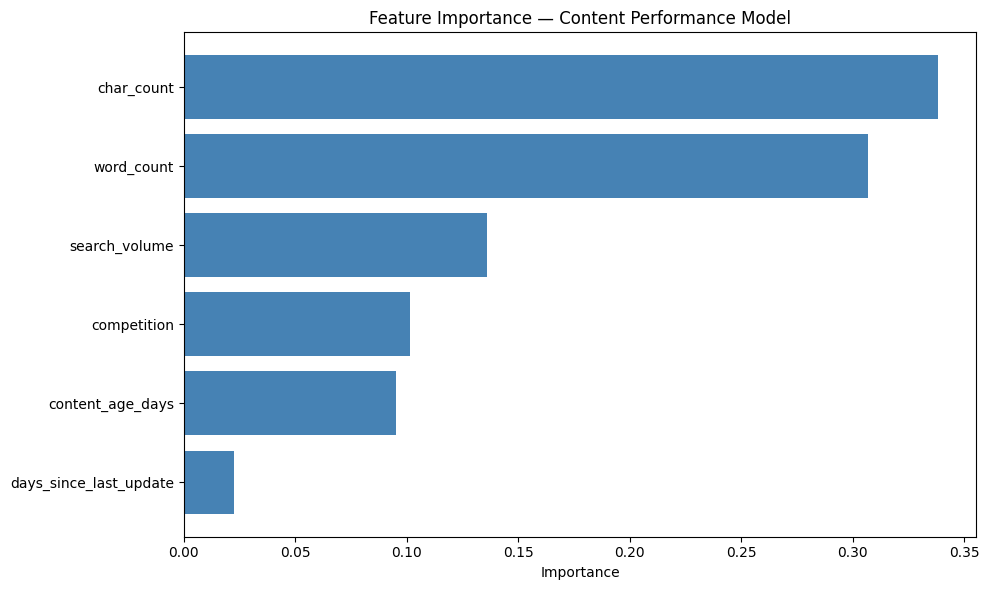

✅ Figure exported to: work/figures/feature_importance.png


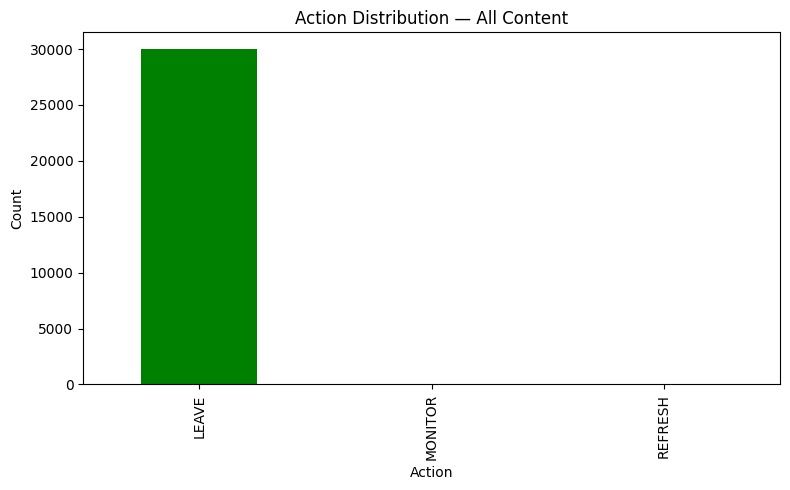

✅ Figure exported to: work/figures/action_distribution.png

EXPORT COMPLETE
   Queue: work/outputs/action_queue.csv
   Metrics: work/outputs/metrics.json
   Figures: work/figures/feature_importance.png, action_distribution.png


In [5]:
print("\n" + "="*60)
print("EXPORTS FOR THE PAPER")
print("="*60)

# Create output directories
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# Export ranked queue
queue_path = 'work/outputs/action_queue.csv'
ranked_queue.to_csv(queue_path, index=False)
print(f"✅ Queue exported to: {queue_path}")

# Export metrics JSON
metrics = {
    'rmse': np.sqrt(mean_squared_error(y_test, rf.predict(X_test))),
    'mae': mean_absolute_error(y_test, rf.predict(X_test)),
    'r2': r2_score(y_test, rf.predict(X_test)),
    'spearman': spearmanr(y_test, rf.predict(X_test))[0],
    'train_size': len(X_train),
    'test_size': len(X_test),
    'feature_importance': dict(zip(feature_cols, rf.feature_importances_.tolist()))
}

metrics_path = 'work/outputs/metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✅ Metrics exported to: {metrics_path}")

# Figure: Feature Importance
plt.figure(figsize=(10,6))
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.barh(importances['Feature'], importances['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance — Content Performance Model')
plt.tight_layout()
plt.savefig('work/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Figure exported to: work/figures/feature_importance.png")

# Figure: Action Distribution
plt.figure(figsize=(8,5))
df_sorted['action_label'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.xlabel('Action')
plt.ylabel('Count')
plt.title('Action Distribution — All Content')
plt.tight_layout()
plt.savefig('work/figures/action_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Figure exported to: work/figures/action_distribution.png")

print("\n" + "="*60)
print("EXPORT COMPLETE")
print("="*60)
print(f"   Queue: {queue_path}")
print(f"   Metrics: {metrics_path}")
print(f"   Figures: work/figures/feature_importance.png, action_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.